# Reto 2: Gradiente Descendente desde Cero

## Misión: Encontrar el Valle Perdido

---

```
                   ▄▄▄▄▄▄
              ▄▄▄██████████▄▄▄
          ▄▄██████████████████▄▄
       ▄███████████████████████▄
     ▄██████████████████████████▄
    ████████████████████████████
   ███████ Tú estás ███████████████
   ███████  AQUÍ  ███████████████
   ███████    *   ███████████████
    ████████████████████████████
     ██████████████████████████
      █████████       █████████
       ██████   VALLE  ███████
        ████  (mínimo)  ██████
         ██    ★         ████
          ████████████████
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
```

---

## Contexto de la Misión

**Fecha:** Febrero 2026
**Ubicación:** Laboratorio de Optimización, IPN

### La Situación

Imagina que estás perdido en una montaña cubierta de niebla espesa. No puedes ver nada a más de un metro de distancia. Tu objetivo es llegar al **valle más bajo** (el mínimo de la función).

Lo único que puedes hacer es **sentir la pendiente bajo tus pies**. Si el suelo baja hacia la derecha, das un paso a la derecha. Si baja hacia la izquierda, das un paso a la izquierda.

Este es exactamente el principio del **gradiente descendente**, el algoritmo más fundamental del Machine Learning. Cada vez que un modelo se entrena, está "bajando la montaña" de la función de error.

Tu misión: implementarlo desde cero.

---

## Objetivos del Reto

Al completar este reto, habrás:

1. Implementado gradiente descendente en 1D y 2D
2. Experimentado con diferentes learning rates
3. Graficado la trayectoria de convergencia
4. Descubierto cuándo el algoritmo funciona y cuándo falla
5. Generado un CSV con resultados experimentales

---

## Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Gradiente descendente en 1D | 25 pts |
| **Parte 2** | Experimentación con learning rates | 25 pts |
| **Parte 3** | Gradiente descendente en 2D | 25 pts |
| **Parte 4** | Análisis y generación de CSV | 25 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | SGD con mini-batches | +15 pts |

---

## Configuración Inicial

Ejecuta esta celda para preparar tu laboratorio.

In [4]:
# ================================================================
# CONFIGURACION DEL LABORATORIO - NO MODIFICAR
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracion visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("\u2554\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2557")
print("\u2551     LABORATORIO DE OPTIMIZACI\u00d3N - GRADIENTE DESCENDENTE   \u2551")
print("\u2551                                                           \u2551")
print("\u2551   Misi\u00f3n: Encontrar el Valle Perdido                      \u2551")
print("\u2551   Herramienta: Gradiente Descendente desde Cero           \u2551")
print("\u2551                                                           \u2551")
print("\u255a\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u2550\u255d")

╔═══════════════════════════════════════════════════════════╗
║     LABORATORIO DE OPTIMIZACIÓN - GRADIENTE DESCENDENTE   ║
║                                                           ║
║   Misión: Encontrar el Valle Perdido                      ║
║   Herramienta: Gradiente Descendente desde Cero           ║
║                                                           ║
╚═══════════════════════════════════════════════════════════╝


## Las Funciones Objetivo

Trabajarás con dos funciones:

### Función 1D:
$$f(x) = (x - 3)^2 + 5$$
- Derivada: $f'(x) = 2(x - 3)$
- Mínimo en: $x = 3$, $f(3) = 5$

### Función 2D:
$$f(x, y) = x^2 + y^2 - 4x - 2y + 5$$
- Gradiente: $\nabla f = [2x - 4,\; 2y - 2]$
- Mínimo en: $(x, y) = (2, 1)$, $f(2, 1) = 0$

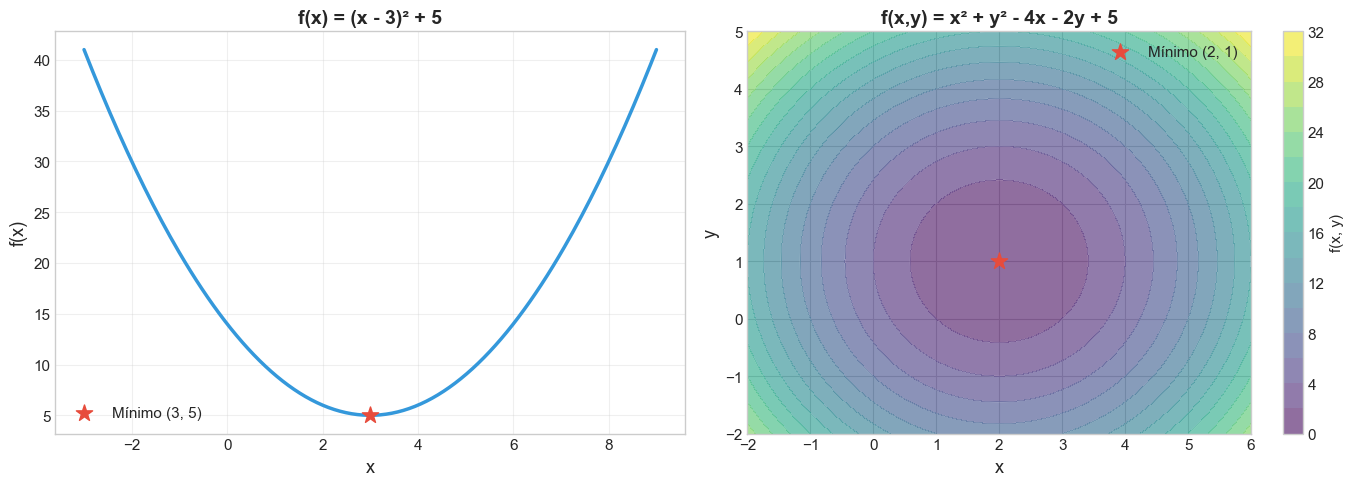

Estas son las dos 'montañas' que deberás descender.
Tu misión: implementar el algoritmo que encuentre el valle (mínimo).


In [5]:
# ================================================================
# FUNCIONES OBJETIVO - PROPORCIONADAS
# ================================================================

# --- Funcion 1D ---
def f_1d(x):
    """f(x) = (x - 3)^2 + 5"""
    return (x - 3)**2 + 5

def df_1d(x):
    """Derivada de f: f'(x) = 2(x - 3)"""
    return 2 * (x - 3)

# --- Funcion 2D ---
def f_2d(x, y):
    """f(x, y) = x^2 + y^2 - 4x - 2y + 5"""
    return x**2 + y**2 - 4*x - 2*y + 5

def grad_2d(x, y):
    """Gradiente de f: [2x - 4, 2y - 2]"""
    return np.array([2*x - 4, 2*y - 2])

# Visualizacion de las funciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Funcion 1D ---
x = np.linspace(-3, 9, 200)
axes[0].plot(x, f_1d(x), color='#3498db', linewidth=2.5)
axes[0].scatter([3], [5], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (3, 5)')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('f(x) = (x - 3)\u00b2 + 5', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Funcion 2D (contornos) ---
x2 = np.linspace(-2, 6, 200)
y2 = np.linspace(-2, 5, 200)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = f_2d(X2, Y2)

contour = axes[1].contourf(X2, Y2, Z2, levels=20, cmap='viridis', alpha=0.6)
axes[1].contour(X2, Y2, Z2, levels=20, colors='white', alpha=0.3, linewidths=0.5)
plt.colorbar(contour, ax=axes[1], label='f(x, y)')
axes[1].scatter([2], [1], color='#e74c3c', s=150, marker='*', zorder=5, label='M\u00ednimo (2, 1)')
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('y', fontsize=13)
axes[1].set_title('f(x,y) = x\u00b2 + y\u00b2 - 4x - 2y + 5', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Estas son las dos 'monta\u00f1as' que deber\u00e1s descender.")
print("Tu misi\u00f3n: implementar el algoritmo que encuentre el valle (m\u00ednimo).")

---

# PARTE 1: Gradiente Descendente en 1D (25 puntos)

## Descendiendo la Montaña Unidimensional

El algoritmo de gradiente descendente en 1D es simple:

```
Repetir hasta convergencia:
    1. Calcular la derivada en el punto actual:  g = f'(x)
    2. Actualizar la posición:  x = x - lr * g
```

### Ejercicio 1.1: Implementa la función de gradiente descendente 1D (15 puntos)

Completa la función `gradiente_descendente_1d()`. Debe:
- Recibir: punto inicial, learning rate, número máximo de iteraciones, tolerancia
- Retornar: punto final, valor mínimo encontrado, número de iteraciones, historial de x, historial de f(x)
- Detenerse si el cambio en x es menor que la tolerancia (convergencia)

In [11]:
def gradiente_descendente_1d(x_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para la funcion f(x) = (x - 3)^2 + 5
    
    Parametros:
    -----------
    x_inicial : float
        Punto de inicio
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si |x_nuevo - x_actual| < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float - Valor final de x
        'f_final': float - Valor de f(x_final)
        'iteraciones': int - Numero de iteraciones realizadas
        'convergido': bool - Si el algoritmo convergio
        'historial_x': list - Valores de x en cada iteracion
        'historial_f': list - Valores de f(x) en cada iteracion
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================


        # 1. Inicializa las variables:
    x_actual = x_inicial
    historial_x = [x_inicial]
    historial_f = [f_1d(x_inicial)]
    convergido = False
    iteraciones_realizadas = 0
    
    # 2. Loop principal (max_iter iteraciones):
    for i in range(max_iter):
        iteraciones_realizadas += 1
        
        # a. Calcula el gradiente: g = df_1d(x_actual)
        g = df_1d(x_actual)
        
        # b. Actualiza: x_nuevo = x_actual - learning_rate * g
        x_nuevo = x_actual - learning_rate * g
        
        # c. Guarda en historial
        historial_x.append(x_nuevo)
        historial_f.append(f_1d(x_nuevo))
        
        # d. Verifica convergencia: si |x_nuevo - x_actual| < tolerancia -> convergido
        if abs(x_nuevo - x_actual) < tolerancia:
            convergido = True
            x_actual = x_nuevo
            break
            
        # e. Actualiza x_actual = x_nuevo
        x_actual = x_nuevo
        
    # 3. Retorna el diccionario con resultados
    return {
        'x_final': x_actual,
        'f_final': f_1d(x_actual),
        'iteraciones': iteraciones_realizadas,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_f': historial_f
    }

    
    


### Ejercicio 1.2: Prueba tu implementación (10 puntos)

Ejecuta el gradiente descendente con los siguientes parámetros y verifica que funciona.

In [12]:
# Prueba basica
resultado = gradiente_descendente_1d(
    x_inicial=-2.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 1D")
print("=" * 50)
print(f"Punto inicial:     x = -2.0")
print(f"Learning rate:     0.1")
print(f"\nResultados:")
print(f"  x final:         {resultado['x_final']:.6f}  (esperado: 3.0)")
print(f"  f(x) final:      {resultado['f_final']:.6f}  (esperado: 5.0)")
print(f"  Iteraciones:     {resultado['iteraciones']}")
print(f"  Convergido:      {resultado['convergido']}")

# Verificacion
error = abs(resultado['x_final'] - 3.0)
if error < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 1D
Punto inicial:     x = -2.0
Learning rate:     0.1

Resultados:
  x final:         2.999996  (esperado: 3.0)
  f(x) final:      5.000000  (esperado: 5.0)
  Iteraciones:     63
  Convergido:      True

  RESULTADO: Correcto (error = 0.000004)


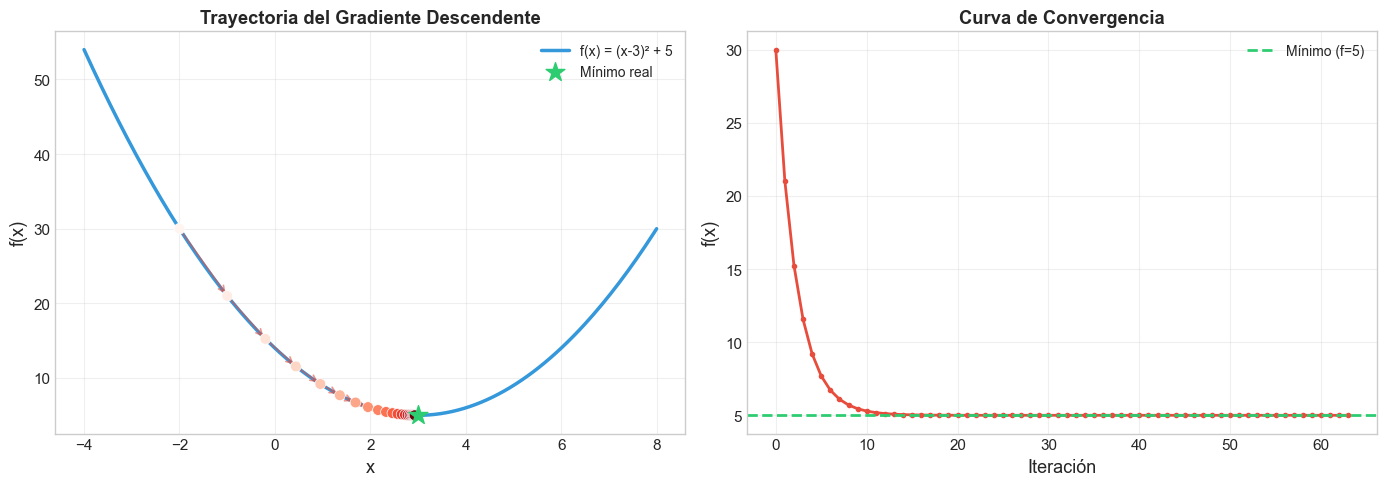

In [13]:
# VISUALIZACION: Grafica la trayectoria de tu gradiente descendente

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Grafica 1: Trayectoria sobre la funcion ---
x_range = np.linspace(-4, 8, 200)
axes[0].plot(x_range, f_1d(x_range), color='#3498db', linewidth=2.5, label='f(x) = (x-3)\u00b2 + 5')

hx = resultado['historial_x']
hf = resultado['historial_f']

# Mostrar solo los primeros 20 pasos para claridad
n_mostrar = min(20, len(hx))
axes[0].scatter(hx[:n_mostrar], hf[:n_mostrar], c=range(n_mostrar),
                cmap='Reds', s=60, zorder=5, edgecolors='white', linewidth=0.5)
for i in range(min(10, n_mostrar - 1)):
    axes[0].annotate('', xy=(hx[i+1], hf[i+1]), xytext=(hx[i], hf[i]),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.2, alpha=0.6))

axes[0].scatter([3], [5], color='#2ecc71', s=200, marker='*', zorder=6, label='M\u00ednimo real')
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('f(x)', fontsize=13)
axes[0].set_title('Trayectoria del Gradiente Descendente', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- Grafica 2: Convergencia ---
axes[1].plot(range(len(hf)), hf, 'o-', color='#e74c3c', linewidth=2, markersize=3)
axes[1].axhline(y=5, color='#2ecc71', linestyle='--', linewidth=2, label='M\u00ednimo (f=5)')
axes[1].set_xlabel('Iteraci\u00f3n', fontsize=13)
axes[1].set_ylabel('f(x)', fontsize=13)
axes[1].set_title('Curva de Convergencia', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gd_1d_trayectoria.png', dpi=150, bbox_inches='tight')
plt.show()

---

# PARTE 2: Experimentación con Learning Rates (25 puntos)

## El Parámetro Más Crítico

Ahora experimenta con diferentes learning rates para descubrir cómo afectan la convergencia.

### Ejercicio 2.1: Ejecuta experimentos (15 puntos)

Prueba los siguientes learning rates: `0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5`

Todos desde el mismo punto inicial: `x = -2.0`

In [19]:
# ============================================================
# TU CODIGO AQUI: Ejecuta experimentos con diferentes learning rates
# ============================================================

learning_rates_prueba = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_inicial_prueba = -2.0
max_iter_prueba = 200

# Almacenar resultados
resultados_lr = []

# TU CODIGO: Para cada learning rate, ejecuta gradiente_descendente_1d
# y guarda los resultados en la lista resultados_lr

for lr in learning_rates_prueba:
    resultado = gradiente_descendente_1d(
        x_inicial=x_inicial_prueba, 
        learning_rate=lr, 
        max_iter=max_iter_prueba
    )
    resultados_lr.append(resultado)

# Mostrar tabla de resultados
print("EXPERIMENTOS CON DIFERENTES LEARNING RATES")
print("=" * 80)
print(f"{'LR':>8} {'x_final':>12} {'f(x)_final':>12} {'Iteraciones':>12} {'Convergi\u00f3':>12}")
print("-" * 60)

for lr, res in zip(learning_rates_prueba, resultados_lr):
    print(f"{lr:>8.3f} {res['x_final']:>12.6f} {res['f_final']:>12.6f} {res['iteraciones']:>12} {str(res['convergido']):>12}")

EXPERIMENTOS CON DIFERENTES LEARNING RATES
      LR      x_final   f(x)_final  Iteraciones    Convergió
------------------------------------------------------------
   0.001    -0.350258    16.224229          200        False
   0.010     2.912060     5.007733          200        False
   0.100     2.999996     5.000000           63         True
   0.500     3.000000     5.000000            2         True
   0.900     3.000000     5.000000           73         True
   1.000    -2.000000    30.000000          200        False
   1.500 -8034690221294951377709810461705813012611014968913964176506880.000000 64556246952172714741397979300075296858242644820730587820766483913516190550421029865741133832003445785897579299318687334400.000000          200        False


### Ejercicio 2.2: Visualiza la comparación (10 puntos)

Crea una gráfica comparativa que muestre la trayectoria y convergencia de cada learning rate.

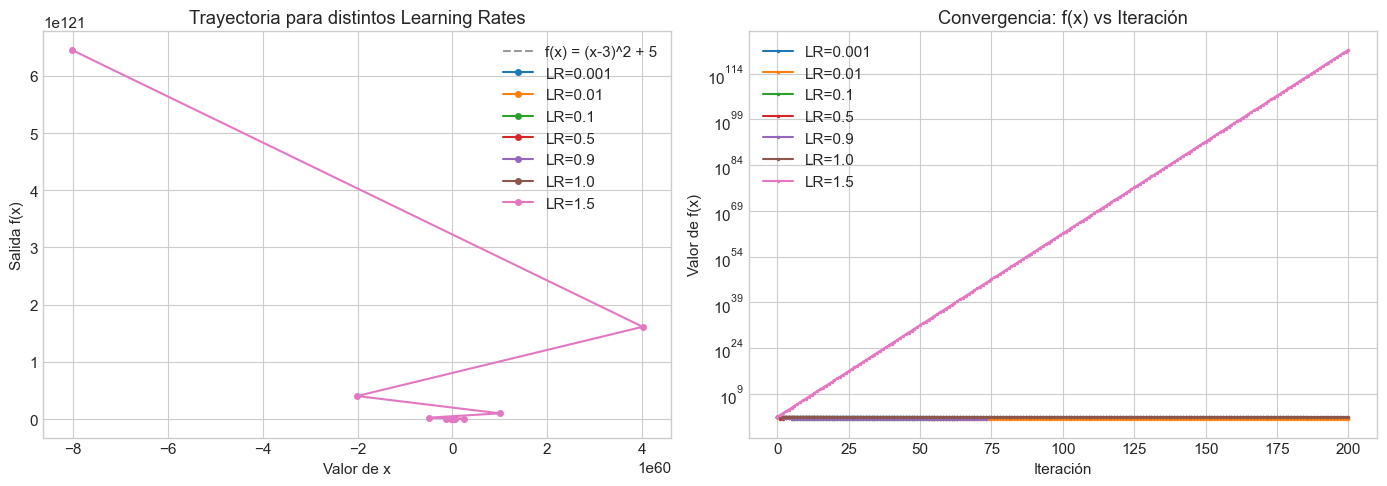

In [21]:
# ============================================================
# TU CODIGO AQUI: Grafica comparativa de learning rates
# ============================================================

# Crea dos graficas:
# 1. Trayectoria sobre f(x) para cada LR (con diferentes colores)
# 2. Curva de convergencia f(x) vs iteracion para cada LR

# Pista: usa fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Pista: usa colores distintos para cada LR

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- GRAFICA 1: Trayectoria sobre f(x) ---
# urva original de fondo como referencia
x_base = np.linspace(-3, 9, 100)
y_base = (x_base - 3)**2 + 5     # f(x) = (x - 3)^2 + 5
axes[0].plot(x_base, y_base, 'k--', label='f(x) = (x-3)^2 + 5', alpha=0.4)

# graficar la "bajada" de cada learning rate
for lr, res in zip(learning_rates_prueba, resultados_lr):
    hx = res['historial_x']
    hf = res['historial_f']
    # líneas y puntos marcando el progreso
    axes[0].plot(hx, hf, marker='o', markersize=4, label=f'LR={lr}')

axes[0].set_title('Trayectoria para distintos Learning Rates')
axes[0].set_xlabel('Valor de x')
axes[0].set_ylabel('Salida f(x)')
axes[0].legend()


# --- GRAFICA 2: Curva de convergencia ---
# valor de la función f(x) respecto al número de iteración
for lr, res in zip(learning_rates_prueba, resultados_lr):
    hf = res['historial_f']
    iteraciones = range(len(hf)) # eje X basado en la cantidad de elementos
    
    axes[1].plot(iteraciones, hf, marker='.', markersize=3, label=f'LR={lr}')

axes[1].set_title('Convergencia: f(x) vs Iteración')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Valor de f(x)')
axes[1].set_yscale('log') # escala logarítmica es útil si los valores crecen mucho con LR altos
axes[1].legend()

plt.tight_layout()
plt.show()




**Responde estas preguntas basandote en tus experimentos:**

1. **\u00bfQu\u00e9 pasa con un learning rate muy peque\u00f1o (0.001)?**
   - *Tu respuesta:* Se va a avanzar con pasos extremadamente pequeños, lo que va a causar que se necesiten muchísimas iteraciones para llegar al mínimo.

2. **\u00bfCu\u00e1l consideras el mejor learning rate y por qu\u00e9?**
   - *Tu respuesta:* El mejor learning rate es el 0.5, ya que es el que llega más rápido al mínimo sin divergir. Solo funciona este learning rate solo para este caso en específico.

3. **\u00bfQu\u00e9 pasa con learning rates >= 1.0?**
   - *Tu respuesta:* Con un learning rate de 1.0, la función diverge, es decir, los valores de f(x) aumentan sin control. Con valores mayores a 1.0, los pasos son tan grandes que cada vez rebota más lejos del mínimo, es decir, el algoritmo diverge hacia el infinito.

4. **\u00bfPor qu\u00e9 un learning rate de exactamente 1.0 tiene un comportamiento especial para esta funci\u00f3n?**
   - *Tu respuesta:*  Porque el tamaño del paso multiplica exactamente por 2 la distancia que hay entre el punto actual y el mínimo. Al dar el paso, el punto "rebota" y cae de forma simétrica del otro lado de la parábola. 

---

# PARTE 3: Gradiente Descendente en 2D (25 puntos)

## Navegando una Superficie

Ahora el reto se pone más interesante: dos parámetros simultáneamente.

```
En 1D: un solo paso, una sola dirección
En 2D: el gradiente tiene dos componentes [dx, dy]
       Debes mover AMBOS parámetros a la vez

   x_nuevo = x_actual - lr * df/dx
   y_nuevo = y_actual - lr * df/dy
```

### Ejercicio 3.1: Implementa gradiente descendente 2D (15 puntos)

In [31]:
def gradiente_descendente_2d(x_inicial, y_inicial, learning_rate, max_iter=1000, tolerancia=1e-6):
    """
    Implementa gradiente descendente para f(x,y) = x^2 + y^2 - 4x - 2y + 5
    
    Parametros:
    -----------
    x_inicial : float
        Valor inicial de x
    y_inicial : float
        Valor inicial de y
    learning_rate : float
        Tamano del paso (alpha)
    max_iter : int
        Numero maximo de iteraciones
    tolerancia : float
        Si la norma del gradiente < tolerancia, se considera convergido
    
    Retorna:
    --------
    dict con:
        'x_final': float
        'y_final': float
        'f_final': float - Valor de f(x_final, y_final)
        'iteraciones': int
        'convergido': bool
        'historial_x': list
        'historial_y': list
        'historial_f': list
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa:
    x_actual, y_actual = x_inicial, y_inicial
    historial_x = [x_inicial]
    historial_y = [y_inicial]
    historial_f = [f_2d(x_inicial, y_inicial)]
    convergido = False
    iteraciones_realizadas = 0
    
    # 2. Loop principal:
    for i in range(max_iter):
        iteraciones_realizadas += 1
        
        # a. Calcula gradiente: g = grad_2d(x_actual, y_actual) -> [gx, gy]
        g = grad_2d(x_actual, y_actual)
        
        # d. Verifica convergencia: si ||gradiente|| < tolerancia -> convergido
        if np.linalg.norm(g) < tolerancia:
            convergido = True
            break
            
        # b. Actualiza ambos parametros (restamos el gradiente multiplicado por lr)
        x_nuevo = x_actual - learning_rate * g[0]
        y_nuevo = y_actual - learning_rate * g[1]
        
        # c. Guarda en historiales
        historial_x.append(x_nuevo)
        historial_y.append(y_nuevo)
        historial_f.append(f_2d(x_nuevo, y_nuevo))
        
        # e. Actualiza x_actual, y_actual
        x_actual, y_actual = x_nuevo, y_nuevo
    
    # 3. Retorna diccionario con resultados
    return {
        'x_final': x_actual,
        'y_final': y_actual,
        'f_final': f_2d(x_actual, y_actual),
        'iteraciones': iteraciones_realizadas,
        'convergido': convergido,
        'historial_x': historial_x,
        'historial_y': historial_y,
        'historial_f': historial_f
    }


### Ejercicio 3.2: Prueba y visualiza en 2D (10 puntos)

Ejecuta tu implementación y crea una visualización con mapa de contornos mostrando la trayectoria.

In [32]:
# Prueba basica 2D
resultado_2d = gradiente_descendente_2d(
    x_inicial=-1.0,
    y_inicial=4.0,
    learning_rate=0.1,
    max_iter=100
)

print("PRUEBA DE GRADIENTE DESCENDENTE 2D")
print("=" * 50)
print(f"Punto inicial:    ({-1.0}, {4.0})")
print(f"Learning rate:    0.1")
print(f"\nResultados:")
print(f"  (x, y) final:   ({resultado_2d['x_final']:.6f}, {resultado_2d['y_final']:.6f})")
print(f"  f(x,y) final:   {resultado_2d['f_final']:.6f}  (esperado: 0.0)")
print(f"  Iteraciones:    {resultado_2d['iteraciones']}")
print(f"  Convergido:     {resultado_2d['convergido']}")

# Verificacion
error_2d = np.sqrt((resultado_2d['x_final'] - 2)**2 + (resultado_2d['y_final'] - 1)**2)
if error_2d < 0.01:
    print(f"\n  RESULTADO: Correcto (error = {error_2d:.6f})")
else:
    print(f"\n  RESULTADO: Revisa tu implementaci\u00f3n (error = {error_2d:.6f})")

PRUEBA DE GRADIENTE DESCENDENTE 2D
Punto inicial:    (-1.0, 4.0)
Learning rate:    0.1

Resultados:
  (x, y) final:   (2.000000, 1.000000)
  f(x,y) final:   0.000000  (esperado: 0.0)
  Iteraciones:    73
  Convergido:     True

  RESULTADO: Correcto (error = 0.000000)


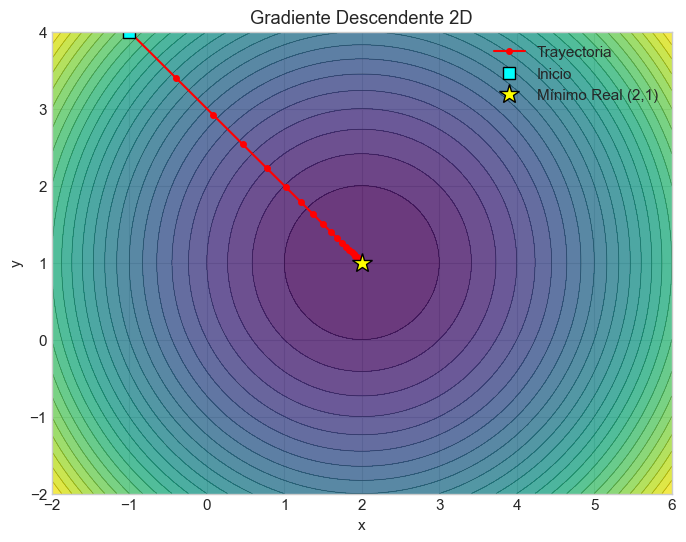

In [36]:
# ============================================================
# TU CODIGO AQUI: Visualizacion del gradiente descendente 2D
# ============================================================

# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
# 2. La trayectoria del gradiente descendente como puntos conectados
# 3. El punto de inicio marcado
# 4. El minimo real marcado con una estrella

# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria


historial_x = resultado_2d['historial_x']
historial_y = resultado_2d['historial_y']

fig, ax = plt.subplots(figsize=(8, 6))
# Crea una grafica con mapa de contornos que muestre:
# 1. Los contornos de la funcion f(x, y)
x_vals = np.linspace(-2, 6, 100)
y_vals = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + Y**2 - 4*X - 2*Y + 5
# Pista: usa ax.contourf() para el fondo y ax.contour() para las lineas
ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.8)
ax.contour(X, Y, Z, levels=25, colors='black', alpha=0.3, linewidths=0.5)
# 2. La trayectoria del gradiente descendente como puntos conectados
# Pista: usa ax.plot(historial_x, historial_y, 'o-') para la trayectoria
ax.plot(historial_x, historial_y, 'o-', color='red', markersize=4, label='Trayectoria')
# 3. El punto de inicio marcado
ax.plot(historial_x[0], historial_y[0], 's', color='cyan', markeredgecolor='black', markersize=8, label='Inicio')
# 4. El minimo real marcado con una estrella
ax.plot(2, 1, '*', color='yellow', markeredgecolor='black', markersize=15, label='Mínimo Real (2,1)')
ax.set_title('Gradiente Descendente 2D')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()




In [38]:
# ============================================================
# EXTRA: Prueba con diferentes puntos iniciales en 2D
# ============================================================

# Prueba al menos 3 puntos iniciales diferentes y compara los resultados
puntos_iniciales = [
    (-1.0, 4.0),
    (5.0, -1.0),
    (0.0, 0.0),
]

# TU CODIGO: ejecuta GD para cada punto inicial y muestra resultados


# learning rate fijo de 0.1 
lr_prueba = 0.1

print("EXPERIMENTOS: DISTINTOS PUNTOS DE INICIO EN 2D")
print("=" * 70)
print(f"{'Pto. Inicial':<15} | {'x_final':>9} | {'y_final':>9} | {'Iteraciones':>11} | {'¿Convergió?'}")
print("-" * 70)

for x_i, y_i in puntos_iniciales:
    # gradiente descendente para cada punto inicial
    res_punto = gradiente_descendente_2d(
        x_inicial=x_i, 
        y_inicial=y_i, 
        learning_rate=lr_prueba
    )
    
    # string para facilitar la visualización del pto de inicio
    str_inicio = f"({x_i}, {y_i})"
    
    # fila de resumen
    print(f"{str_inicio:<15} | {res_punto['x_final']:>9.4f} | {res_punto['y_final']:>9.4f} | {res_punto['iteraciones']:>11} | {str(res_punto['convergido']):>11}")

print("=" * 70)
print("NOTA: El mínimo real está en (2.0000, 1.0000).")


EXPERIMENTOS: DISTINTOS PUNTOS DE INICIO EN 2D
Pto. Inicial    |   x_final |   y_final | Iteraciones | ¿Convergió?
----------------------------------------------------------------------
(-1.0, 4.0)     |    2.0000 |    1.0000 |          73 |        True
(5.0, -1.0)     |    2.0000 |    1.0000 |          72 |        True
(0.0, 0.0)      |    2.0000 |    1.0000 |          70 |        True
NOTA: El mínimo real está en (2.0000, 1.0000).


---

# PARTE 4: Análisis y Generación de CSV (25 puntos)

## Documentando tus Experimentos

### Ejercicio 4.1: Genera el CSV de experimentos (15 puntos)

Crea un DataFrame con TODOS los experimentos que realizaste y guárdalo como CSV.

El CSV debe tener las siguientes columnas:
- `learning_rate`: valor del learning rate
- `dimension`: "1D" o "2D"
- `x_inicial`: punto inicial en x
- `y_inicial`: punto inicial en y (NaN para 1D)
- `x_final`: valor final de x
- `y_final`: valor final de y (NaN para 1D)
- `valor_minimo`: f(x) o f(x,y) final
- `iteraciones`: número de iteraciones
- `convergido`: True/False

In [40]:
# Lista para guardar todos los registros
datos_experimentos = []

# ---------------------------------------------------------
# 1. Ejecutar Experimentos 1D
# ---------------------------------------------------------
lrs_1d = [0.001, 0.01, 0.1, 0.5, 0.9, 1.0, 1.5]
x_ini_1d = -2.0

for lr in lrs_1d:
    res = gradiente_descendente_1d(x_inicial=x_ini_1d, learning_rate=lr, max_iter=200)
    
    # Agregamos los resultados como un diccionario (que luego será una fila del DataFrame)
    datos_experimentos.append({
        'funcion': '1D',
        'learning_rate': lr,
        'x_inicial': x_ini_1d,
        'y_inicial': None, # No aplica para 1D
        'iteraciones': res['iteraciones'],
        'convergido': res['convergido'],
        'f_final': res['f_final']
    })

# ---------------------------------------------------------
# 2. Ejecutar Experimentos 2D
# ---------------------------------------------------------
lrs_2d = [0.001, 0.01, 0.1, 0.5]
puntos_ini_2d = [(-1.0, 4.0), (5.0, -1.0), (0.0, 0.0)]

for x_i, y_i in puntos_ini_2d:
    for lr in lrs_2d:
        res = gradiente_descendente_2d(x_inicial=x_i, y_inicial=y_i, learning_rate=lr, max_iter=200)
        
        datos_experimentos.append({
            'funcion': '2D',
            'learning_rate': lr,
            'x_inicial': x_i,
            'y_inicial': y_i,
            'iteraciones': res['iteraciones'],
            'convergido': res['convergido'],
            'f_final': res['f_final']
        })

# ---------------------------------------------------------
# 3. y 4. Crear el DataFrame y Guardarlo
# ---------------------------------------------------------
df_experimentos = pd.DataFrame(datos_experimentos)
df_experimentos.to_csv('experimentos_gd.csv', index=False)

print(f"'experimentos_gd.csv' se genero exitosamente")

# Mostramos las primeras filas para verificar que quedó bien armado
df_experimentos.head()


'experimentos_gd.csv' se genero exitosamente


,funcion,learning_rate,x_inicial,y_inicial,iteraciones,convergido,f_final
0,1D,0.001,-2.0,NaN,200,False,16.224229
1,1D,0.010,-2.0,NaN,200,False,5.007733
2,1D,0.100,-2.0,NaN,63,True,5.000000
3,1D,0.500,-2.0,NaN,2,True,5.000000
4,1D,0.900,-2.0,NaN,73,True,5.000000


In [41]:
# Muestra el CSV generado
print("CONTENIDO DEL CSV DE EXPERIMENTOS")
print("=" * 80)

# df_experimentos = pd.read_csv('experimentos_gd.csv')
# print(df_experimentos.to_string(index=False))
# print(f"\nTotal de experimentos: {len(df_experimentos)}")


df_experimentos = pd.read_csv('experimentos_gd.csv')
print(df_experimentos.to_string(index=False))
print(f"\nTotal de experimentos: {len(df_experimentos)}")


CONTENIDO DEL CSV DE EXPERIMENTOS
funcion  learning_rate  x_inicial  y_inicial  iteraciones  convergido       f_final
     1D          0.001       -2.0        NaN          200       False  1.622423e+01
     1D          0.010       -2.0        NaN          200       False  5.007733e+00
     1D          0.100       -2.0        NaN           63        True  5.000000e+00
     1D          0.500       -2.0        NaN            2        True  5.000000e+00
     1D          0.900       -2.0        NaN           73        True  5.000000e+00
     1D          1.000       -2.0        NaN          200       False  3.000000e+01
     1D          1.500       -2.0        NaN          200       False 6.455625e+121
     2D          0.001       -1.0        4.0          200       False  8.081445e+00
     2D          0.010       -1.0        4.0          200       False  5.568046e-03
     2D          0.100       -1.0        4.0           73        True  1.989520e-13
     2D          0.500       -1.0        4

### Ejercicio 4.2: Reflexión final (10 puntos)

**Responde las siguientes preguntas:**

1. **\u00bfCu\u00e1l es el rango de learning rates que funciona bien para estas funciones?**
   - *Tu respuesta:* Le sirven mucho los LR entre 0.01 y 0.9. Ya que con valores muy grandes parece que la aproximación "rebota" y no converge.

2. **\u00bfEl punto inicial afecta si el algoritmo converge? \u00bfAfecta cu\u00e1ntas iteraciones necesita?**
   - *Tu respuesta:* Para las funciones convexas (como las parabolas), el punto inicial no afecta si el algoritmo converge, pero si afecta cuantas iteraciones necesita. Esto es porque solo existe un mínimo.

3. **\u00bfQu\u00e9 pasar\u00eda si la funci\u00f3n tuviera m\u00faltiples m\u00ednimos locales? (piensa en una funci\u00f3n como `sin(x) + x\u00b2/10`)**
   - *Tu respuesta:* Si la función tuviera múltiples mínimos locales, el algoritmo podría converger a un mínimo local en lugar del mínimo global. Esto es porque el algoritmo solo puede moverse en la dirección del gradiente, por lo que no puede "saltar" de un mínimo local a otro.

4. **Conecta con ML: Cuando entrenas un modelo, los pesos del modelo son como `x` e `y`, y la funci\u00f3n de costo es como `f(x,y)`. \u00bfPor qu\u00e9 es importante elegir bien el learning rate al entrenar?**
   - *Tu respuesta:* Es importante elegir bien el learning rate al entrenar porque si es muy grande, el algoritmo puede diverger. Si es muy pequeño, el algoritmo puede tardar mucho en converger.

5. **\u00bfQu\u00e9 ventaja tiene usar el gradiente (pendiente) en lugar de simplemente probar valores al azar?**
   - *Tu respuesta:* Sirve para indicar en qué dirección está la mejor bajada, donde adivinar sería muy ineficiente si es que se tuviesen millones de datos.

---

# BONUS: SGD con Mini-Batches (+15 puntos)

## Gradiente Descendente Estocástico

En la práctica, los datasets son enormes (millones de muestras). Calcular el gradiente con TODOS los datos en cada paso es muy lento.

**Solución: Stochastic Gradient Descent (SGD)**

En lugar de usar todos los datos, usa un **subconjunto aleatorio** (mini-batch) en cada iteración.

```
Gradient Descent (GD):        SGD con Mini-Batches:

Usa TODOS los datos            Usa un SUBCONJUNTO aleatorio
en cada paso                   en cada paso

  Gradiente exacto               Gradiente aproximado
  pero lento                     pero rapido
  Trayectoria suave              Trayectoria ruidosa
                                 (pero llega al mismo lugar)
```

### Ejercicio Bonus: Implementa SGD para regresión lineal

Implementa SGD para ajustar una regresión lineal `y = wx + b` con mini-batches.

In [44]:
# ================================================================
# DATOS PARA SGD
# ================================================================

np.random.seed(42)

# Generar datos: y = 3x + 7 + ruido
n_datos = 200
X_sgd = np.random.uniform(0, 10, n_datos)
y_sgd = 3 * X_sgd + 7 + np.random.normal(0, 2, n_datos)

print(f"Datos generados: {n_datos} muestras")
print(f"Relaci\u00f3n real: y = 3x + 7 + ruido")
print(f"\nTu objetivo: encontrar w \u2248 3 y b \u2248 7 usando SGD")

Datos generados: 200 muestras
Relación real: y = 3x + 7 + ruido

Tu objetivo: encontrar w ≈ 3 y b ≈ 7 usando SGD


In [45]:
def sgd_regresion_lineal(X, y, learning_rate=0.01, epochs=50, batch_size=32):
    """
    Implementa SGD con mini-batches para regresion lineal y = wx + b
    
    Parametros:
    -----------
    X : array - Datos de entrada
    y : array - Valores objetivo
    learning_rate : float
    epochs : int - Numero de pasadas completas por los datos
    batch_size : int - Tamano del mini-batch
    
    Retorna:
    --------
    dict con:
        'w_final': float - Pendiente aprendida
        'b_final': float - Intercepto aprendido
        'historial_loss': list - MSE por epoch
        'historial_w': list - w por epoch
        'historial_b': list - b por epoch
    """
    
    # ============================================================
    # TU CODIGO AQUI
    # ============================================================
    
    # 1. Inicializa w = 0, b = 0
    # 2. Para cada epoch:
    #    a. Mezcla los indices aleatoriamente
    #    b. Para cada mini-batch:
    #       - Selecciona batch_size muestras
    #       - Calcula prediccion: y_pred = w * X_batch + b
    #       - Calcula error: error = y_batch - y_pred
    #       - Calcula gradientes:
    #           dw = -2/batch_size * sum(error * X_batch)
    #           db = -2/batch_size * sum(error)
    #       - Actualiza: w = w - lr * dw, b = b - lr * db
    #    c. Calcula MSE del epoch completo y guarda en historial
    
    
    
    # 1. Inicializa w = 0, b = 0
    w = 0.0
    b = 0.0
    
    n_muestras = len(X)
    historial_loss = []
    historial_w = []
    historial_b = []
    
    # 2. Para cada epoch:
    for epoch in range(epochs):
        
        # a. Mezcla los indices aleatoriamente
        indices = np.random.permutation(n_muestras)
        X_mezclado = X[indices]
        y_mezclado = y[indices]
        
        # b. Para cada mini-batch: (avanzamos en saltos de batch_size)
        for i in range(0, n_muestras, batch_size):
            
            # Selecciona batch_size muestras
            X_batch = X_mezclado[i:i + batch_size]
            y_batch = y_mezclado[i:i + batch_size]
            
            # Extraemos tamaño real del batch (el último salto podría ser menor a 32)
            tam_batch = len(X_batch) 
            
            # Calcula prediccion: y_pred = w * X_batch + b
            y_pred = w * X_batch + b
            
            # Calcula error: error = y_batch - y_pred
            error = y_batch - y_pred
            
            # Calcula gradientes:
            dw = (-2.0 / tam_batch) * np.sum(error * X_batch)
            db = (-2.0 / tam_batch) * np.sum(error)
            
            # Actualiza: w = w - lr * dw, b = b - lr * db
            w = w - learning_rate * dw
            b = b - learning_rate * db
            
        # c. Calcula MSE del epoch completo y guarda en historial
        
        # La predicción sobre TODOS los datos originales usando este w y b ajustado
        prediccion_total = w * X + b
        
        # Creamos el Mean Squared Error (MSE)
        mse = np.mean((y - prediccion_total)**2)
        
        historial_loss.append(mse)
        historial_w.append(w)
        historial_b.append(b)
    # El punto 3 era retornar el diccionario:
    return {
        'w_final': w,
        'b_final': b,
        'historial_loss': historial_loss,
        'historial_w': historial_w,
        'historial_b': historial_b
    }

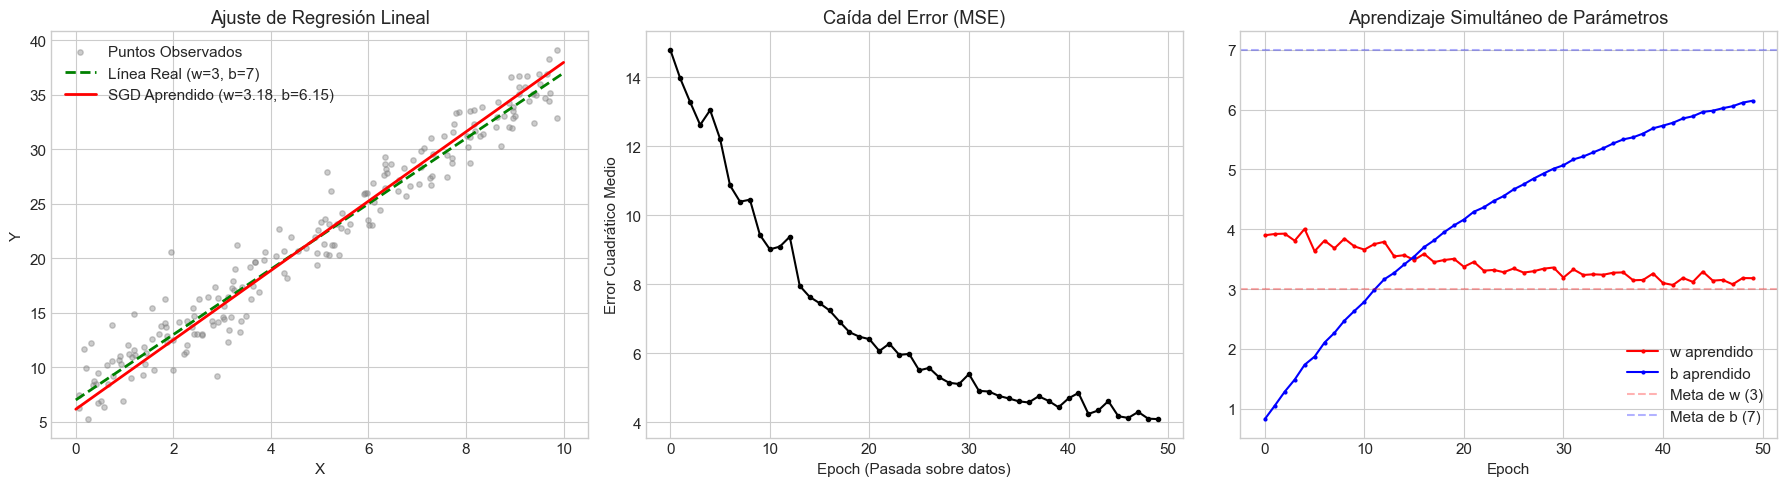

In [46]:
# Ejecuta SGD y visualiza resultados

# resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# TU CODIGO: Crea graficas comparando:
# 1. Datos + linea aprendida por SGD vs linea real
# 2. Curva de loss por epoch
# 3. Evolucion de w y b por epoch

import matplotlib.pyplot as plt
import numpy as np

# 1. Ejecuta SGD
resultado_sgd = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=32)

# Desempaquetamos los resultados
w_fin = resultado_sgd['w_final']
b_fin = resultado_sgd['b_final']
h_loss = resultado_sgd['historial_loss']
h_w = resultado_sgd['historial_w']
h_b = resultado_sgd['historial_b']

# Creamos 3 gráficas (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------------------------------------------------------------
# GRÁFICA 1: Datos dispersos + Linea aprendida vs Linea real
# -------------------------------------------------------------
axes[0].scatter(X_sgd, y_sgd, color='gray', alpha=0.4, label='Puntos Observados', s=15)

# Línea del modelo REAL que debíamos adivinar (y = 3x + 7)
x_rango = np.linspace(0, 10, 100)
axes[0].plot(x_rango, 3 * x_rango + 7, 'g--', linewidth=2, label='Línea Real (w=3, b=7)')

# Línea del modelo ENTRENADO artificialmente por tu IA
axes[0].plot(x_rango, w_fin * x_rango + b_fin, 'r-', linewidth=2, label=f'SGD Aprendido (w={w_fin:.2f}, b={b_fin:.2f})')

axes[0].set_title('Ajuste de Regresión Lineal')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].legend()

# -------------------------------------------------------------
# GRÁFICA 2: Curva de Error (Loss) por Epoch
# -------------------------------------------------------------
axes[1].plot(range(len(h_loss)), h_loss, 'k.-')
axes[1].set_title('Caída del Error (MSE)')
axes[1].set_xlabel('Epoch (Pasada sobre datos)')
axes[1].set_ylabel('Error Cuadrático Medio')

# -------------------------------------------------------------
# GRÁFICA 3: Evolucion de w y b por cada Epoch
# -------------------------------------------------------------
epocas = range(len(h_w))

# Valores aprendidos gradualmente
axes[2].plot(epocas, h_w, 'r.-', label='w aprendido', markersize=4)
axes[2].plot(epocas, h_b, 'b.-', label='b aprendido', markersize=4)

# Líneas punteadas horizontales marcando las metas PERFECTAS
axes[2].axhline(y=3, color='r', linestyle='--', alpha=0.3, label='Meta de w (3)')
axes[2].axhline(y=7, color='b', linestyle='--', alpha=0.3, label='Meta de b (7)')

axes[2].set_title('Aprendizaje Simultáneo de Parámetros')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()



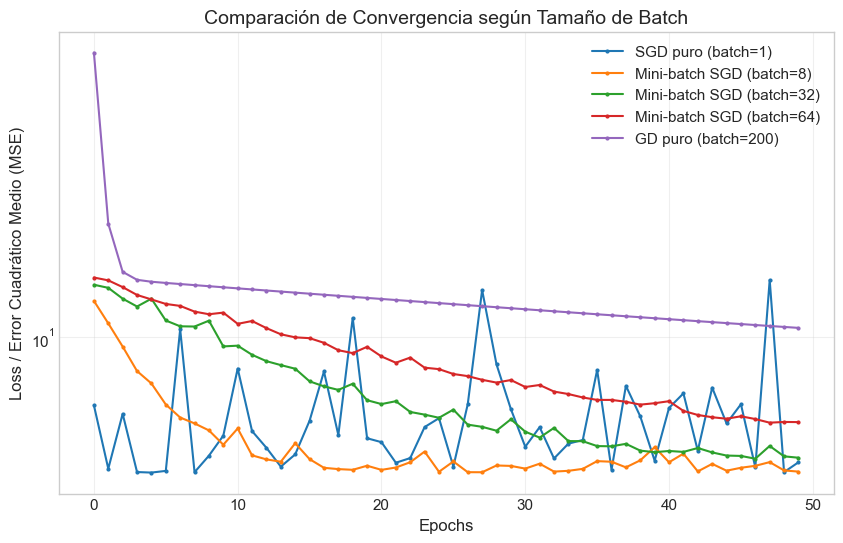

In [49]:
# EXTRA: Compara GD vs SGD con diferentes batch_sizes

# batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

# TU CODIGO: ejecuta para cada batch_size y compara convergencia

import matplotlib.pyplot as plt

# experimentos
batch_sizes = [1, 8, 32, 64, n_datos]  # 1=SGD puro, n_datos=GD puro

plt.figure(figsize=(10, 6))

for bs in batch_sizes:
    # entrenamiento 
    res = sgd_regresion_lineal(X_sgd, y_sgd, learning_rate=0.01, epochs=50, batch_size=bs)
    
    # MSE
    h_loss = res['historial_loss']
    
    # etiqueta 
    if bs == 1:
        etiqueta = "SGD puro (batch=1) "
    elif bs == n_datos:
        etiqueta = f"GD puro (batch={n_datos}) "
    else:
        etiqueta = f"Mini-batch SGD (batch={bs})"
        
    # Agregamos la curva de este tamaño de batch a nuestra gráfica general
    plt.plot(range(len(h_loss)), h_loss, marker='.', markersize=4, label=etiqueta)

# gráfica
plt.title("Comparación de Convergencia según Tamaño de Batch", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss / Error Cuadrático Medio (MSE)", fontsize=12)
plt.yscale('log') # La escala logarítmica ayuda a ver mejor cómo bajan los errores juntos
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)


plt.show()




**Preguntas Bonus:**

1. **\u00bfQu\u00e9 diferencia notas entre GD puro (batch_size=n) y SGD (batch_size=1)?**
   - *Tu respuesta:* El GD revisa los 200 datos en el mismo momento y da un paso por cada epoca. El GD es muy estable (bajando lentamente) y el SGD bastante érratico (bajando rapidamente).

2. **\u00bfCu\u00e1l batch_size te dio los mejores resultados? \u00bfPor qu\u00e9?**
   - *Tu respuesta:* El batch_size que me dio los mejores resultados fue el 8. Esto se debe a que es un buen balance entre la velocidad del SGD y la estabilidad del GD.

3. **\u00bfPor qu\u00e9 la curva de loss de SGD es m\u00e1s ruidosa que la de GD?**
   - *Tu respuesta:* El ruido en la curva de SGD ocurre porque calcula el gradiente y actualiza los pesos usando un solo ejemplo a la vez, la dirección hacia la que apunta el gradiente cambia drásticamente en cada iteración, generando esos saltos en la gráfica.

---

# Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Función `gradiente_descendente_1d()` implementada y probada
- [ ] **Parte 2:** Experimentos con 7 learning rates ejecutados y visualizados
- [ ] **Parte 3:** Función `gradiente_descendente_2d()` implementada y visualizada
- [ ] **Parte 4:** CSV `experimentos_gd.csv` generado y preguntas respondidas
- [ ] **Bonus (opcional):** SGD implementado y comparado con GD

## Archivos a Entregar

1. Este notebook completado (`.ipynb`)
2. `experimentos_gd.csv` con columnas:
   - `learning_rate, dimension, x_inicial, y_inicial, x_final, y_final, valor_minimo, iteraciones, convergido`

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Implementaciones correctas de GD | 30 |
| Visualizaciones claras e informativas | 15 |
| Respuestas reflexivas y bien argumentadas | 15 |
| CSV generado correctamente | 10 |
| **Total** | **100** |

---

## Lección Aprendida

El gradiente descendente es el corazón del Machine Learning moderno:

```
ALGORITMO                        USA GRADIENTE DESCENDENTE
═════════                        ═══════════════════════

Regresión Lineal                 Para encontrar w y b que minimizan MSE
Regresión Logística              Para encontrar pesos que minimizan log-loss
Redes Neuronales                 Backpropagation = gradiente descendente en capas
GPT / ChatGPT / Claude           Entrenado con variantes de SGD (Adam)
Stable Diffusion                 Gradientes en espacio latente

Todo lo que implementaste hoy es la BASE de todo el ML moderno.
```

---

_Reto 2 - Gradiente Descendente desde Cero | Modelado Predictivo 2026_